<a href="https://colab.research.google.com/github/daaastis/fundamentals-of-data-mining/blob/main/%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%B4%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ЭТАП 1: ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ CENSUS INCOME 
[Успешно] Общий размер очищенного датасета: (45222, 15)

 ЭТАП 2: ПОСТРОЕНИЕ И ВИЗУАЛИЗАЦИЯ ДЕРЕВА РЕШЕНИЙ (100% ДАННЫХ) 


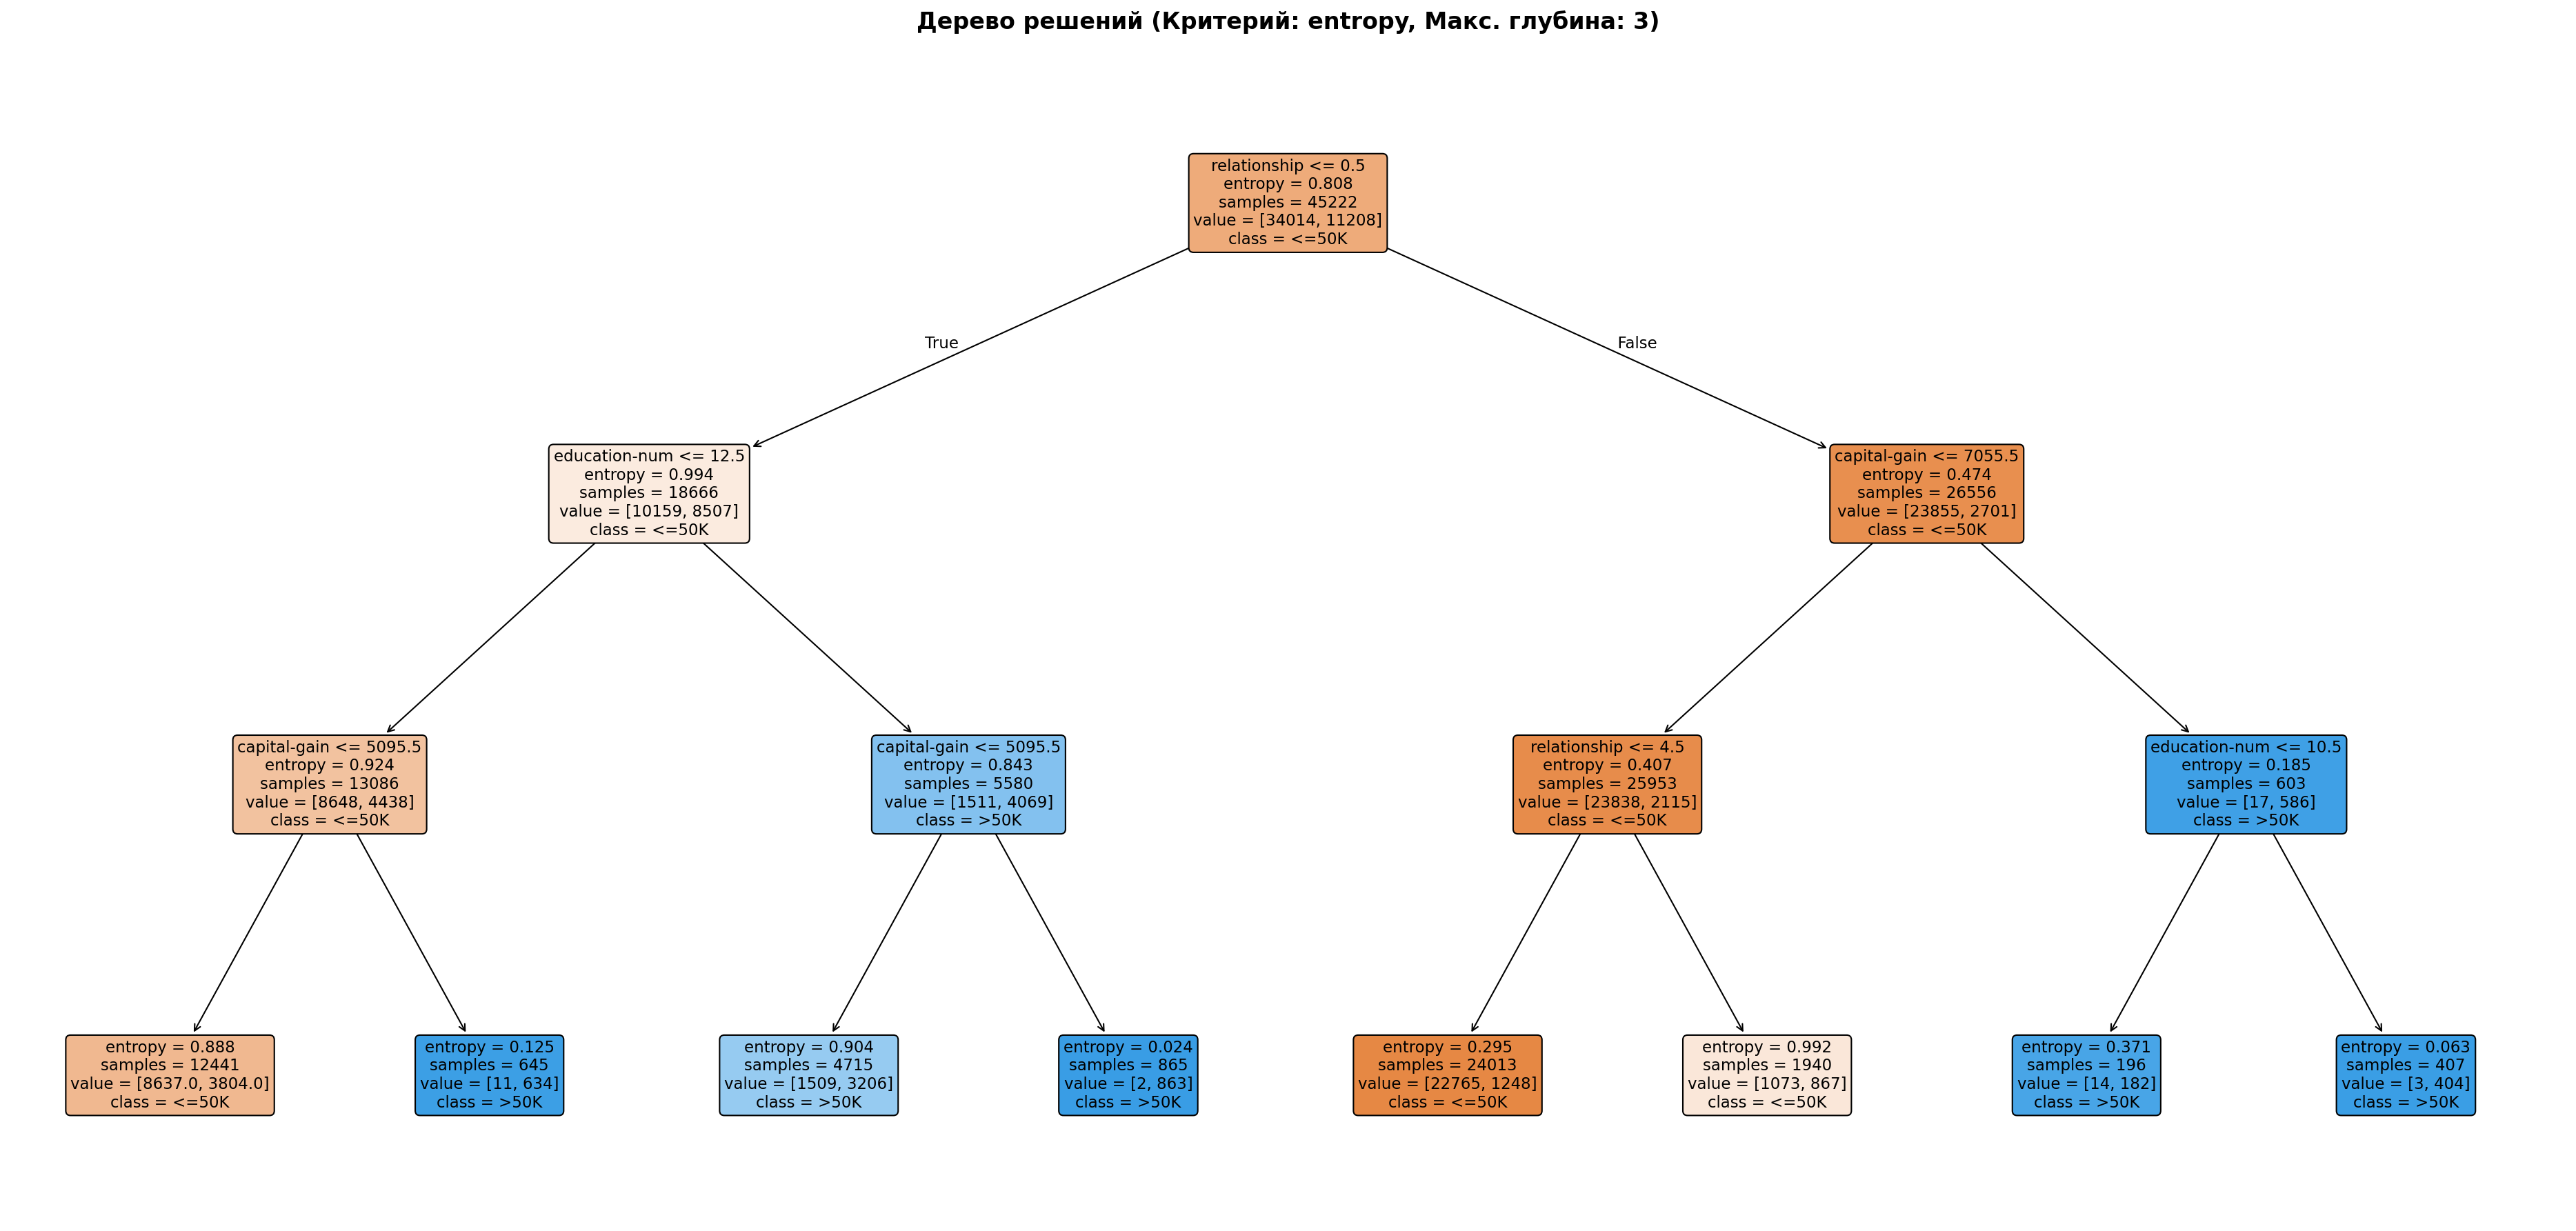

 ЭТАП 3: ЭКСПЕРИМЕНТЫ С РАЗЛИЧНЫМИ СООТНОШЕНИЯМИ ВЫБОРОК 
╒═══════════════════════════════╤════════════╤═════════════╤══════════╤════════════╕
│ Соотношение (Обучение:Тест)   │   Accuracy │   Precision │   Recall │   F1-Score │
╞═══════════════════════════════╪════════════╪═════════════╪══════════╪════════════╡
│ 60% : 40%                     │     0.848  │      0.7832 │   0.5289 │     0.6314 │
├───────────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ 70% : 30%                     │     0.8494 │      0.7731 │   0.5584 │     0.6484 │
├───────────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ 80% : 20%                     │     0.8509 │      0.8058 │   0.5448 │     0.6501 │
├───────────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ 90% : 10%                     │     0.8519 │      0.8098 │   0.5448 │     0.6514 │
╘═══════════════════════════════╧════════════╧═════════════╧══════════╧════════════╛

 ЭТАП 

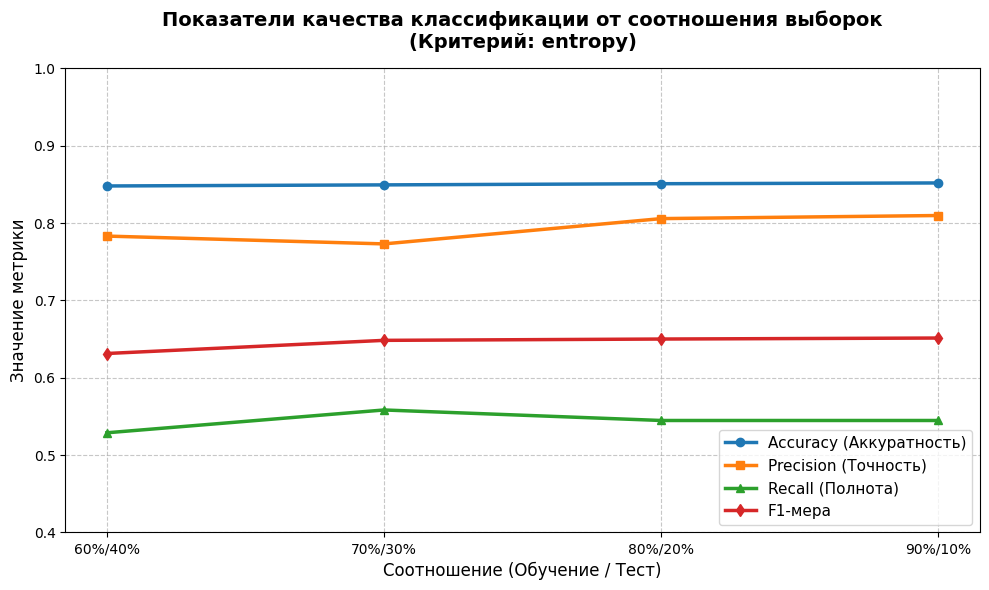

In [3]:
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

# Установка tabulate для красивых таблиц
!pip install tabulate -q
from tabulate import tabulate

print("=" * 70)
print(" ЭТАП 1: ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ CENSUS INCOME ")
print("=" * 70)

# Ссылки на датасет Adult (Census Income) с репозитория UCI
train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
test_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

train_file = "adult.data"
test_file = "adult.test"

column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Загрузка тренировочного набора, если его нет
if not os.path.exists(train_file):
    print("[+] Скачивание обучающей выборки adult.data...")
    urllib.request.urlretrieve(train_url, train_file)

# Загрузка тестового набора, если его нет
if not os.path.exists(test_file):
    print("[+] Скачивание тестовой выборки adult.test...")
    urllib.request.urlretrieve(test_url, test_file)

# Чтение данных
df_train = pd.read_csv(train_file, names=column_names, skipinitialspace=True, na_values="?")
df_test = pd.read_csv(test_file, names=column_names, skiprows=1, skipinitialspace=True, na_values="?")

# Объединяем в единый массив для корректной предобработки (кодирования категорий)
df_full = pd.concat([df_train, df_test], ignore_index=True)

# Очистка пропущенных значений
df_full = df_full.dropna()

# Очистка целевой переменной от точек (в adult.test метки записаны как '>50K.' и '<=50K.')
df_full['income'] = df_full['income'].str.replace('.', '', regex=False)

# Преобразование целевой переменной в бинарный формат (0 и 1)
df_full['income'] = df_full['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)

# Кодирование категориальных признаков через LabelEncoder
categorical_cols = df_full.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df_full[col] = le.fit_transform(df_full[col].astype(str))

print(f"[Успешно] Общий размер очищенного датасета: {df_full.shape}\n")

# Разделение на признаки (X) и целевую переменную (y)
X = df_full.drop('income', axis=1)
y = df_full['income']

# =================================================================
# 2. ЭКСПЕРИМЕНТ 1: ПОСТРОЕНИЕ ДЕРЕВА И ВИЗУАЛИЗАЦИЯ
# =================================================================
print("=" * 70)
print(" ЭТАП 2: ПОСТРОЕНИЕ И ВИЗУАЛИЗАЦИЯ ДЕРЕВА РЕШЕНИЙ (100% ДАННЫХ) ")
print("=" * 70)

criterion_choice = 'entropy'  # Критерий разбиения

# Ограничиваем глубину (например, max_depth=3), чтобы дерево было компактным и читаемым
clf_full = DecisionTreeClassifier(criterion=criterion_choice, max_depth=3, random_state=42)
clf_full.fit(X, y)

# Увеличиваем размер холста (например, ширина 25, высота 12)
plt.figure(figsize=(25, 12), dpi=150)
plot_tree(clf_full,
          feature_names=X.columns.tolist(),
          class_names=['<=50K', '>50K'],
          filled=True,
          rounded=True,
          fontsize=11) # Управляем размером шрифта текста в узлах

plt.title(f"Дерево решений (Критерий: {criterion_choice}, Макс. глубина: 3)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# =================================================================
# 3. ЭКСПЕРИМЕНТ 2: ВАРЬИРОВАНИЕ СООТНОШЕНИЯ ОБУЧАЮЩЕЙ И ТЕСТОВОЙ ВЫБОРОК
# =================================================================
print("=" * 70)
print(" ЭТАП 3: ЭКСПЕРИМЕНТЫ С РАЗЛИЧНЫМИ СООТНОШЕНИЯМИ ВЫБОРОК ")
print("=" * 70)

train_ratios = [0.60, 0.70, 0.80, 0.90]
results = []

for ratio in train_ratios:
    test_ratio = round(1.0 - ratio, 2) # Корректное округление до десятых
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=ratio, random_state=42)

    model = DecisionTreeClassifier(criterion=criterion_choice, max_depth=6, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        'Соотношение (Обучение:Тест)': f"{int(ratio*100)}% : {int(round(test_ratio, 2)*100)}%",
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

df_results = pd.DataFrame(results)
print(tabulate(df_results, headers='keys', tablefmt='fancy_grid', showindex=False))
print()

# =================================================================
# 4. ВИЗУАЛИЗАЦИЯ ПОКАЗАТЕЛЕЙ КАЧЕСТВА КЛАССИФИКАЦИИ
# =================================================================
print("=" * 70)
print(" ЭТАП 4: ПОСТРОЕНИЕ ДИАГРАММ КАЧЕСТВА КЛАССИФИКАЦИИ ")
print("=" * 70)

ratios_str = [f"{int(r*100)}%/{int(round(1-r, 2)*100)}%" for r in train_ratios]

plt.figure(figsize=(10, 6))
plt.plot(ratios_str, df_results['Accuracy'], marker='o', label='Accuracy (Аккуратность)', linewidth=2.5)
plt.plot(ratios_str, df_results['Precision'], marker='s', label='Precision (Точность)', linewidth=2.5)
plt.plot(ratios_str, df_results['Recall'], marker='^', label='Recall (Полнота)', linewidth=2.5)
plt.plot(ratios_str, df_results['F1-Score'], marker='d', label='F1-мера', linewidth=2.5)

plt.title(f"Показатели качества классификации от соотношения выборок\n(Критерий: {criterion_choice})", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Соотношение (Обучение / Тест)", fontsize=12)
plt.ylabel("Значение метрики", fontsize=12)
plt.ylim(0.4, 1.0)  # Расширяем шкалу Y, чтобы все метрики поместились корректно
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()